In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu

df = pd.read_csv("data.csv")
print(df.columns.tolist())
print(df.head())
print(df.shape)

['Unnamed: 0', 'group', 'rank', 'team', 'matches_played', 'wins', 'draws', 'losses', 'goals_scored', 'goals_against', 'goal_difference', 'points', 'expected_goal_scored', 'exp_goal_conceded', 'exp_goal_difference', 'exp_goal_difference_per_90']
   Unnamed: 0  group  rank         team  matches_played  wins  draws  losses  \
0           0      1     1  Netherlands               3     2      1       0   
1           1      1     2      Senegal               3     2      0       1   
2           2      1     3      Ecuador               3     1      1       1   
3           3      1     4        Qatar               3     0      0       3   
4           4      2     1      England               3     2      1       0   

   goals_scored  goals_against  goal_difference  points  expected_goal_scored  \
0             5              1                4       7                   2.4   
1             5              4                1       6                   3.8   
2             4              3 

In [3]:
team_candidates = ["team", "Team", "country", "Country", "squad", "Squad"]
goal_candidates = ["goals", "Goals", "goal_per_game", "goals_per_game", "goals_scored", "goal_scored"]
xg_candidates = ["expected_goal_scored", "xg_per_game", "xG", "xg"]
shots_on_target_candidates = ["shots_on_target_per_game", "shot_on_target_per_game", "shots_on_target", "Shots on Target"]

team_col = next((c for c in team_candidates if c in df.columns), None)
goal_col = next((c for c in goal_candidates if c in df.columns), None)
xg_col = next((c for c in xg_candidates if c in df.columns), None)
sot_col = next((c for c in shots_on_target_candidates if c in df.columns), None)

print("team_col:", team_col)
print("goal_col:", goal_col)
print("xg_col:", xg_col)
print("sot_col:", sot_col)

if xg_col is None:
    raise ValueError("xG kolonu bulunamadı")
if goal_col is None:
    raise ValueError("Goal kolonu bulunamadı")

if team_col is None:
    df["team_name"] = [f"Team_{i+1}" for i in range(len(df))]
    team_col = "team_name"

df = df[[team_col, xg_col, goal_col] + ([sot_col] if sot_col else [])].copy()
df["performance"] = df[goal_col] - df[xg_col]
df["overperform"] = (df["performance"] > 0).astype(int)

print(df.head())


team_col: team
goal_col: goals_scored
xg_col: expected_goal_scored
sot_col: None
          team  expected_goal_scored  goals_scored  performance  overperform
0  Netherlands                   2.4             5          2.6            1
1      Senegal                   3.8             5          1.2            1
2      Ecuador                   3.7             4          0.3            1
3        Qatar                   1.4             1         -0.4            0
4      England                   5.2             9          3.8            1


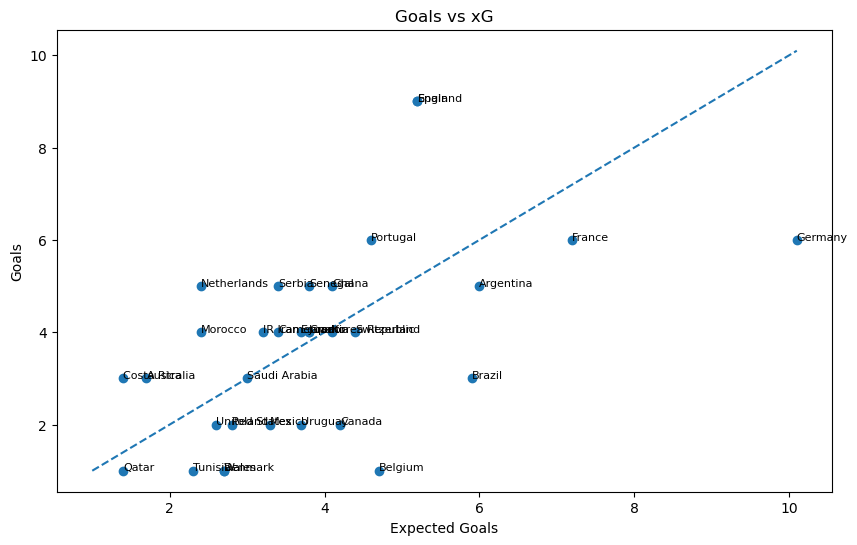

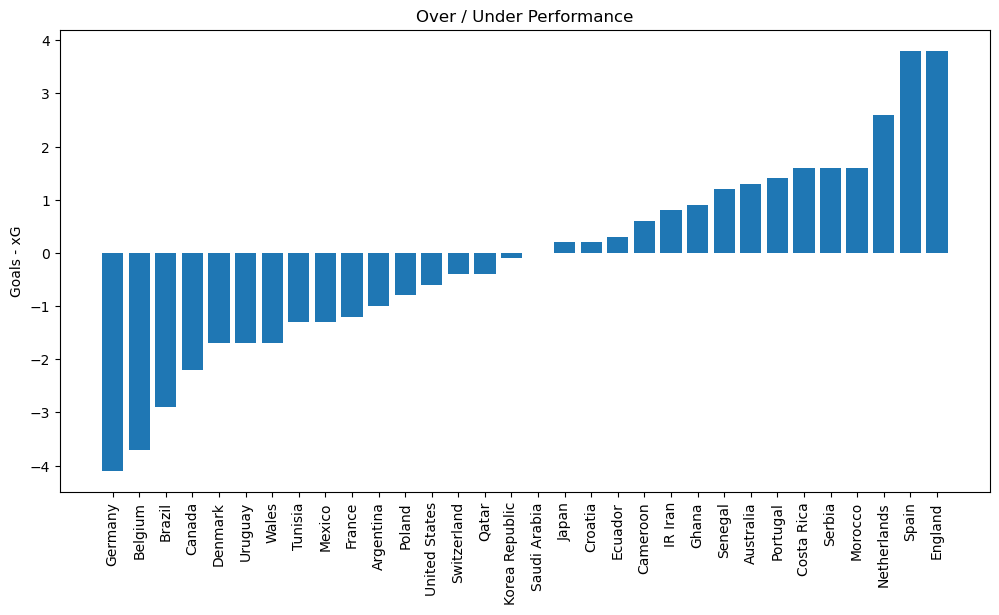

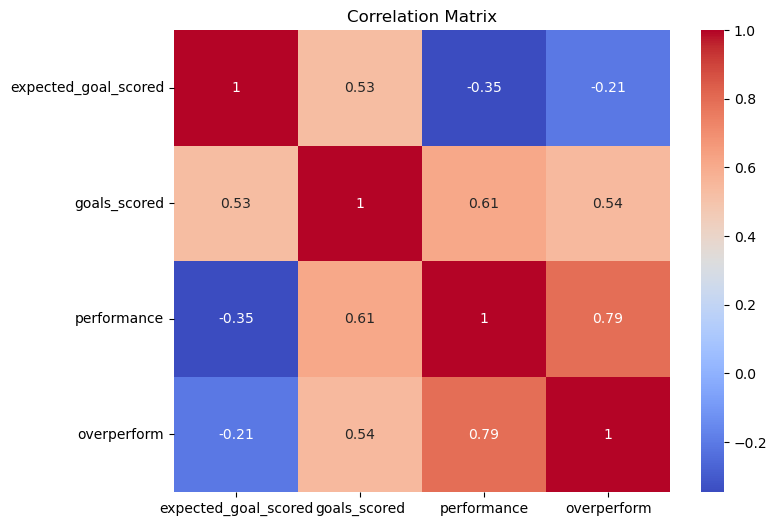

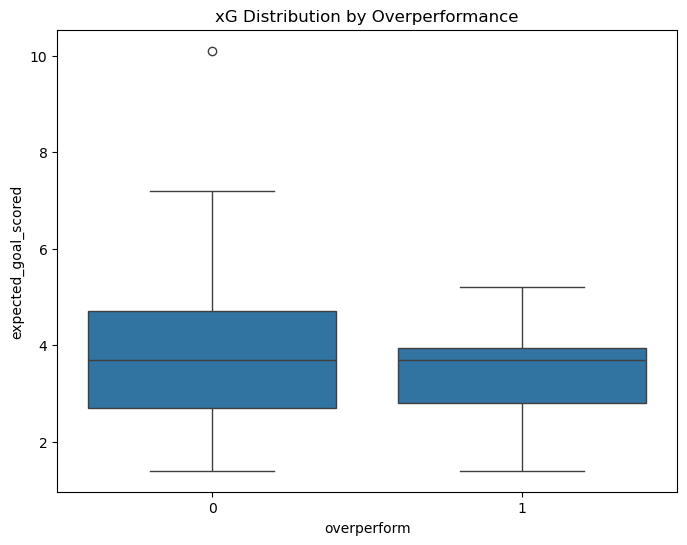

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(df[xg_col], df[goal_col])
for i, txt in enumerate(df[team_col]):
    plt.annotate(txt, (df[xg_col].iloc[i], df[goal_col].iloc[i]), fontsize=8)
mn = min(df[xg_col].min(), df[goal_col].min())
mx = max(df[xg_col].max(), df[goal_col].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("Expected Goals")
plt.ylabel("Goals")
plt.title("Goals vs xG")
plt.show()

plt.figure(figsize=(12,6))
df_sorted = df.sort_values("performance")
plt.bar(df_sorted[team_col], df_sorted["performance"])
plt.xticks(rotation=90)
plt.ylabel("Goals - xG")
plt.title("Over / Under Performance")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(x="overperform", y=xg_col, data=df)
plt.title("xG Distribution by Overperformance")
plt.show()


In [5]:
pearson_corr, pearson_p = pearsonr(df[xg_col], df[goal_col])
spearman_corr, spearman_p = spearmanr(df[xg_col], df[goal_col])

group1 = df[df["overperform"] == 1][xg_col]
group0 = df[df["overperform"] == 0][xg_col]
mw_stat, mw_p = mannwhitneyu(group1, group0, alternative="two-sided")

print("Pearson correlation:", pearson_corr)
print("Pearson p-value:", pearson_p)
print("Spearman correlation:", spearman_corr)
print("Spearman p-value:", spearman_p)
print("Mann-Whitney U statistic:", mw_stat)
print("Mann-Whitney p-value:", mw_p)

Pearson correlation: 0.5290158912610223
Pearson p-value: 0.001851811059011803
Spearman correlation: 0.5715493158105397
Spearman p-value: 0.0006331328278879841
Mann-Whitney U statistic: 111.5
Mann-Whitney p-value: 0.5579336491638058


In [6]:
print("Top overperformers:")
print(df.sort_values("performance", ascending=False)[[team_col, xg_col, goal_col, "performance"]].head(5))

print("\nTop underperformers:")
print(df.sort_values("performance", ascending=True)[[team_col, xg_col, goal_col, "performance"]].head(5))

Top overperformers:
           team  expected_goal_scored  goals_scored  performance
4       England                   5.2             9          3.8
17        Spain                   5.2             9          3.8
0   Netherlands                   2.4             5          2.6
27       Serbia                   3.4             5          1.6
20      Morocco                   2.4             4          1.6

Top underperformers:
       team  expected_goal_scored  goals_scored  performance
18  Germany                  10.1             6         -4.1
22  Belgium                   4.7             1         -3.7
24   Brazil                   5.9             3         -2.9
23   Canada                   4.2             2         -2.2
15  Denmark                   2.7             1         -1.7
